# Статистический анализ прибыльности тарифов сотовой связи

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
2. [<b>Предварительная обработка данных</b>](#2)
    <br>[2.1. Преобразование типов данных](#2.1.)
    <br>[2.2. Создание новых признаков](#2.2.)
3. [<b>Исследовательский анализ данных</b>](#3)
    <br>[3.1. Общий уровень отточности клиентов](#3.1.)
    <br>[3.2. Описание поведения пользователей](#3.2.)
    <br>[3.3. Превышение базовых значений по тарифам](#3.3.)
    <br>[3.4. Выручка](#3.4.)
    <br>[3.5. Статистические метрики по тарифам](#3.5.)
    <br>[3.5.1. Распределение количества звонков](#3.5.1.)
    <br>[3.5.2. Распределение продолжительности звонков](#3.5.2.)
    <br>[3.5.3. Распределение количества сообщений](#3.5.3.)
    <br>[3.5.4. Распределение количества потраченного трафика (Мб)](#3.5.4.)
    <br>[3.5.5. Выручка по городам](#3.5.5.)
5. [<b>Проверка статистических гипотез</b>](#4)
    <br>[4.1. Средняя выручка пользователей тарифа «Смарт» и «Ультра» различается](#4.1.)
    <br>[4.2. Средняя выручка с пользователей из Москвы отличается от выручки c пользователей других регионов](#4.2.)
6. [<b>Вывод</b>](#5)

<a id=descr_proj></a>
## Описание проекта
Вы аналитик компании «Мегалайн» — федерального оператора сотовой связи. Клиентам предлагают два тарифных плана: «Смарт» и «Ультра». Чтобы скорректировать рекламный бюджет, коммерческий департамент хочет понять, какой тариф приносит больше денег. Вам предстоит сделать предварительный анализ тарифов на небольшой выборке клиентов. В вашем распоряжении данные 500 пользователей «Мегалайна»: кто они, откуда, каким тарифом пользуются, сколько звонков и сообщений каждый отправил за 2018-й год. Компания «Мегалайн» количество использованных минут и Мб всегда округляет вверх. Если пользователь проговорил всего 1 секунду, в тарифе засчитывается целая минута. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.

## Описание тарифов

| | Тариф «Смарт» | Тариф «Ультра» |
|:--|:--|:--|
| Ежемесячная плата | 550 рублей | 1950 рублей |
| **Включено:** | | |
| минут | 500 | 3000 |
| сообщений | 50 | 1000 |
| Гб интернет-трафика | 15 | 30 |
| **Стоимость сверх тарифного пакета:** | | |
| минута | 3 рубля | 1 рубль |
| сообщение | 3 рубля | 1 рубль |
| 1 Гб интернет-трафика | 200 рублей | 150 рублей |


<a id=descr_data></a>
## Описание данных

В работу поступила серия датафреймов.

Датафрейм `users.csv` , содержащий записи о 500 пользователях, где профиль каждого физического лица имеет следующие 8 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1. | `user_id` | уникальный идентификатор пользователя | 500 уникальных номеров | от 1000 до 1499 |
| 2. | `first_name` | имя пользователя | день | от 24 до 401755 |
| 3. | `last_name` | фамилия пользователя | 419 уникальных фамилий | от 'Ёлчина' до 'Яшина' |
| 4. | `age` | возраст пользователя | полных лет | от 18 до 75 |
| 5. | `reg_date` | дата подключения тарифа | день, месяц, год | от 2018-01-01 до 2018-12-31 |
| 6. | `churn_date` | дата прекращения пользования тарифом | дата расторжения договора, пропуск - договор актуален | 38 - `1`,  462 - `NaN`|
| 7. | `city` | город проживания пользователя | 76 уникальных наименований | от 'Архангельск' до 'Ярославль'|
| 8. | `tarif` | название тарифного плана | 2 уникальных наименования | 'smart', 'ultra' |

Датафрейм `tariffs.csv` , содержащий записи о 2 тарифах, где профиль каждого тарифа имеет следующие 8 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1. | `tariff_name` | название тарифа | уникальное наименование | 'smart', 'ultra' |
| 2. | `rub_monthly_fee` | ежемесячная абонентская плата | рубли | '550', '1950'|
| 3. | `minutes_included` | количество минут разговора в месяц, включённых в абонентскую плату | минута | '500', '3000' |
| 4. | `messages_included` | количество сообщений в месяц, включённых в абонентскую плату| сообщение | '50', '1000'  |
| 5. | `mb_per_month_included` | объём интернет-трафика, включённого в абонентскую плату | мегабайты | '15360', '30720' |
| 6. | `rub_per_minute` |стоимость минуты разговора сверх тарифного пакета | рубли|'1', '3' |
| 7. | `rub_per_message` | стоимость отправки сообщения сверх тарифного пакета | рубли | '1', '3'|
| 8. | `rub_per_gb` | стоимость дополнительного гигабайта интернет-трафика сверх тарифного пакета | рубли | '150', '200' |

Датафрейм `calls.csv` , содержащий 202607 записи о звонках в разрезе следующих 4 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1. | `id` | уникальный номер звонка | уникальное наименование | от 1000_0 до 1499_99 |
| 2. | `call_date` | дата звонка | день | от 2018-01-01 до 2018-12-31 |
| 3. | `duration` | длительность звонка | минута | от 0.0 до 38.0 |
| 4. | `user_id` | идентификатор пользователя, сделавшего звонок | 492 уникальных значения | от 1000 до 1499 |

Датафрейм `messages.csv` , содержащий 123036 записи о звонках в разрезе следующих 3 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1. | `id` | уникальный номер сообщения | уникальное наименование | от 1000_0 до 1499_99 |
| 2. | `message_date` | дата сообщения | день | от 2018-01-02 до 2018-12-31 |
| 3. | `user_id` | идентификатор пользователя, отправившего сообщение | 426 уникальных значения | от 1000 до 1499  |

Датафрейм `internet.csv`, содержащий информацию об интернет-сессиях пользователей объёмом 149396 строк в разрезе 5 признаков:

| № п/п  | Наименование признака   | Краткое описание | Единицы измерения  | Значение |
|--------|:-----------|:-----------------|:-----|:------------------|
| 1. | `Unnamed: 0` |технический столбец | аналог индекса | от 0 до 149395 |
| 2. | `id` | уникальный номер сессии | 149396 уникальных значений | от 1000_0 до 1499_99 |
| 3. | `mb_used` | объём потраченного за сессию интернет-трафика | мегабайт | от 1724.83 до 70003 |
| 4. | `session_date` | дата интернет-сессии | дата | от 2018-01-01 до 2018-12-31 |
| 5. | `user_id` | идентификатор пользователя | 497 уникальных значения | от 1000 до 1499 |

Данные получены посредством последовательного применения методов `len()`, `nunique()`, `min()`, `max()` к указанным датасетам.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
from scipy import stats as st

# настройка визуализации
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
from pylab import rcParams
rcParams['figure.figsize'] = 12,6
sns.set_style('whitegrid', {'axes.grid' : True})

In [2]:
# загрузка данных
calls = pd.read_csv('04_calls.csv')
sessions = pd.read_csv('04_internet.csv')
messages = pd.read_csv('04_messages.csv')
tariffs = pd.read_csv('04_tariffs.csv')
users = pd.read_csv('04_users.csv')

In [3]:
# cобираем все датафреймы в словарь
dfs = {'calls': calls, 'sessions': sessions, 'messages': messages, 'tariffs': tariffs, 'users': users}

In [4]:
# dыводим .head() и .info() для каждого
for name, df in dfs.items():
    print(f"\n{'='*20}{'::'} {name.upper()} {'::'}{'='*20}")
    display(df.head())
    display()
    df.info()


====================:: CALLS ::====================


,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB

====================:: SESSIONS ::====================


,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB

====================:: MESSAGES ::====================


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB

====================:: TARIFFS ::====================


,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 260.0+ bytes

====================:: USERS ::====================


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


**Вывод:** 
анализ полноты и качества данных показывает, что в целом датасеты находятся в хорошем состоянии и пригодны для проведения аналитических исследований. Все пять датафреймов загружены без критических потерь: в транзакционных таблицах (звонки, сессии, сообщения) полностью отсутствуют пропущенные значения, что свидетельствует он надёжности источника. Пропущенные значения в признаке `churn_date` датафрейма с пользователями отражает бизнес-логику: дата ухода фиксируется только в день расторжения договора и прекращения пользования услугами. Идентификаторы во всех таблицах уникальны и согласованы между собой, что позволяет корректно объединять щданные по пользователю для построения комплексных метрик. Особого внимания требует хранение дат в строковом формате, иначе будет невозможным выполнение временных фильтраций, рассчёт интервалов и группировка по периодам. Нам предстоит удалить технический признак `Unnamed: 0` в датафрейме `sessions`, который является артефактом и аналогом индекса. Таким образом, данные могут быть охарактеризованы как полные, хорошо структурированные, требующие минимальной предварительной обработки. 

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1.></a>
### 2.1. Преобразование типов данных

In [5]:
# преобразование к типу данных datetime
tables_to_convert = [
    (users,    ['reg_date', 'churn_date']),
    (calls,    ['call_date']),
    (messages, ['message_date']),
    (sessions, ['session_date'])
]

for df, cols in tables_to_convert:
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

В данных присутствуют звонки с нулевой продолжительностью. Это не ошибка: нулями обозначены пропущенные звонки, поэтому их не нужно удалять. Однако в `calls['duration']` значения дробные. Округлим Эти данные вверх с помощью метода `numpy.ceil()` и приведём к типу `int`.

In [6]:
# округление значений столбца `duration` с помощью np.ceil() и приведение к `int`
calls['duration'] = np.ceil(calls['duration']).astype(int)

In [7]:
# удаление технических артефактов в данных
sessions = sessions.drop(columns='Unnamed: 0')

<a id=2.2.></a>
### 2.2. Создание новых признаков

In [8]:
# месяц в датафрейме `calls`
calls['month'] = calls['call_date'].apply(lambda x: x.month)

In [9]:
# месяц в датафрейме `messages`
messages['month'] = messages['message_date'].apply(lambda x: x.month)

In [10]:
# месяц в датафрейме `sessions`
sessions['month'] = sessions['session_date'].apply(lambda x: x.month)

In [11]:
# количество звонков для каждого пользователя по месяцам
calls_per_month = calls.groupby(['user_id', 'month']).agg(calls=('duration', 'count'))

In [12]:
# вывод первых 20 строк на экран на ознакомление
calls_per_month.head(20).T

user_id 1000                             1001     1002                      \
month     5   6   7   8   9   10  11  12   11  12   6   7   8   9   10  11   
calls     22  43  47  52  58  57  43  46   59  63   15  26  42  36  33  32   

user_id     1003            
month    12   8    9    10  
calls    33   55  134  108

In [13]:
# количество израсходованных минут для каждого пользователя по месяцам
minutes_per_month = calls.groupby(['user_id', 'month']).agg(minutes=('duration', 'sum'))

In [14]:
# вывод первых 20 строк на экран на ознакомление
minutes_per_month.head(20).T

user_id 1000                                    1001      1002                 \
month     5    6    7    8    9    10   11   12   11   12   6    7    8    9    
minutes  159  172  340  408  466  350  338  333  430  414  117  214  289  206   

user_id                1003            
month     10   11   12   8    9    10  
minutes  212  243  236  380  961  855

In [15]:
# количество отправленных сообщений для каждого пользователя по месяцам
messages_per_month = messages.groupby(['user_id', 'month']).agg(messages=('message_date', 'count'))

In [16]:
# вывод первых 20 строк на экран на ознакомление
messages_per_month.head(20).T

user_id  1000                             1002                        1003  \
month      5   6   7   8   9   10  11  12   6   7   8  9   10  11  12   8    
messages   22  60  75  81  57  73  58  70    4  11  13  4  10  16  12   37   

user_id                   
month     9   10  11  12  
messages  91  83  94  75

In [17]:
# количество потраченных мегабайт для каждого пользователя по месяцам
sessions_per_month = sessions.groupby(['user_id', 'month']).agg({'mb_used': 'sum'})

In [18]:
# вывод первых 20 строк на экран на ознакомление
sessions_per_month.head(20).T

user_id     1000                                                              \
month         5         6         7         8         9         10        11   
mb_used  2253.49  23233.77  14003.64  14055.93  14568.91  14702.49  14756.47   

user_id               1001                1002                               \
month         12        11        12        6        7         8         9    
mb_used  9817.61  18429.34  14036.66  10856.82  17580.1  20319.26  16691.08   

user_id                                   1003                      
month          10        11        12       8         9         10  
mb_used  13888.25  18587.28  18113.73  8565.21  12468.87  14768.14

<a id=3></a>
## Шаг 3. Исследовательский анализ данных и подсчёт выручки

В целях проведения комплексного исследования поведения пользователей полагаем необходимым подготовить обобщённый датафрейм `user_behavior` с полными данными. Для каждой пары «пользователь — месяц» будут доступны информация о тарифе, количестве звонков, сообщений и потраченных мегабайтах.

<a id=3.1.></a>
### 3.1. Общий уровень отточности клиентов

In [19]:
# рассчитаем долю отточных клиентов
users['churn_date'].count() / users['churn_date'].shape[0] * 100

np.float64(7.6)

Расторгли договор 7.6% клиентов оператора «Мегалайн» на тарифах «Смарт» и «Ультра».

<a id=3.2.></a>
### 3.2. Описание поведения пользователей

In [20]:
# объединение информации по сообщениям, интернет-сессиям, минутам звонков по каждому пользователю
user_behavior = calls_per_month\
    .merge(messages_per_month, left_index=True, right_index=True, how='outer')\
    .merge(sessions_per_month, left_index=True, right_index=True, how='outer')\
    .merge(minutes_per_month, left_index=True, right_index=True, how='outer')\
    .reset_index()\
    .merge(users, how='left', left_on='user_id', right_on='user_id')\

user_behavior.head()

,user_id,month,calls,messages,mb_used,minutes,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,5,22.0,22.0,2253.49,159.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000,6,43.0,60.0,23233.77,172.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000,7,47.0,75.0,14003.64,340.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000,8,52.0,81.0,14055.93,408.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000,9,58.0,57.0,14568.91,466.0,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


In [21]:
# проверка на пропуски после объединения всех массивов
user_behavior.isna().sum().sort_values(ascending=False)

churn_date    3027
messages       497
calls           40
minutes         40
mb_used         11
month            0
user_id          0
age              0
city             0
first_name       0
last_name        0
reg_date         0
tariff           0
dtype: int64

In [22]:
# заполнение пропусков в объединённом датафрейме нулями
user_behavior['calls'] = user_behavior['calls'].fillna(0)
user_behavior['minutes'] = user_behavior['minutes'].fillna(0)
user_behavior['messages'] = user_behavior['messages'].fillna(0)
user_behavior['mb_used'] = user_behavior['mb_used'].fillna(0)

К полученному датафрейму присоединяем собственно информацию о тарифах.

In [23]:
# переименование столбца `tariff_name` на более простое `tariff`
tariffs = tariffs.rename(columns={'tariff_name': 'tariff'})

In [24]:
# присоединение к даннм о поведении пользователей информации по тарифам
user_behavior = user_behavior.merge(tariffs, on='tariff')

<a id=3.3.></a>
### 3.3. Превышение базовых значений по тарифам

In [25]:
# создаём признаки минут, сообщений и мегабайт, потраченных клиентами сверх значений тарифов
user_behavior['paid_minutes'] = user_behavior['minutes'] - user_behavior['minutes_included']
user_behavior['paid_messages'] = user_behavior['messages'] - user_behavior['messages_included']
user_behavior['paid_mb'] = user_behavior['mb_used'] - user_behavior['mb_per_month_included']

# заполняем нулями те строки, где превышения значения тарифов не закфиксировано
for col in ['paid_messages', 'paid_minutes', 'paid_mb']:
    user_behavior.loc[user_behavior[col] < 0, col] = 0

In [26]:
# создаём признак `paid_gb` - оплаченные гигабайты, для этого мегабайты разделим на 1024
user_behavior['paid_gb'] = np.ceil(user_behavior['paid_mb'] / 1024).astype(int)

<a id=3.4.></a>
### 3.4. Выручка

In [27]:
# создаём признак выручки за каждый вид услуг: за минуты разговора, сообщения и интернет
user_behavior['cost_minutes'] = user_behavior['paid_minutes'] * user_behavior['rub_per_minute']
user_behavior['cost_messages'] = user_behavior['paid_messages'] * user_behavior['rub_per_message']
user_behavior['cost_gb'] = user_behavior['paid_gb'] * user_behavior['rub_per_gb']

In [28]:
# расчёт помесячной выручки с каждого пользователя за все виды услуг
user_behavior['total_cost'] = \
      user_behavior['rub_monthly_fee']\
    + user_behavior['cost_minutes']\
    + user_behavior['cost_messages']\
    + user_behavior['cost_gb']

<a id=3.5.></a>
### 3.5. Статистические метрики по тарифам

In [29]:
# создание статистических метрик для каждой пары месяц - тариф
stats_df = user_behavior.pivot_table(
            index=['month', 'tariff'],\
            values=['calls', 'minutes', 'messages', 'mb_used'],\
            aggfunc=['mean', 'std', 'median'] # cреднее, стандартное отклонение, медиана
).round(2).reset_index()

# формируем порядок признаков в датафрейме с описательными статистиками
stats_df.columns=['month', 'tariff', \
                  'calls_mean', 'calls_std', 'calls_median', \
                  'minutes_mean', 'minutes_std', 'minutes_median',\
                  'messages_mean', 'messages_std', 'messages_median',\
                  'sessions_mean', 'sessions_std', 'sessions_median']

# вывод первых строк на ознакомление
stats_df.head()

,month,tariff,calls_mean,calls_std,calls_median,minutes_mean,minutes_std,minutes_median,messages_mean,messages_std,messages_median,sessions_mean,sessions_std,sessions_median
0,1,smart,27.68,8513.72,18.24,203.85,20.81,6444.68,16.20,154.23,20.5,7096.18,15.0,162.5
1,1,ultra,59.44,13140.68,33.78,428.11,41.64,6865.35,30.67,269.76,51.0,14791.37,32.0,382.0
2,2,smart,40.19,11597.05,24.09,298.69,25.39,6247.35,21.75,190.82,38.5,12553.71,20.0,258.0
3,2,ultra,41.54,11775.94,21.96,297.12,40.97,10644.64,26.77,296.51,25.0,7327.12,5.5,168.0
4,3,smart,54.32,15104.16,31.86,390.05,25.54,5828.24,26.80,191.89,59.0,15670.25,23.0,409.0


<a id=3.5.1.></a>
### 3.5.1. Распределение количества звонков

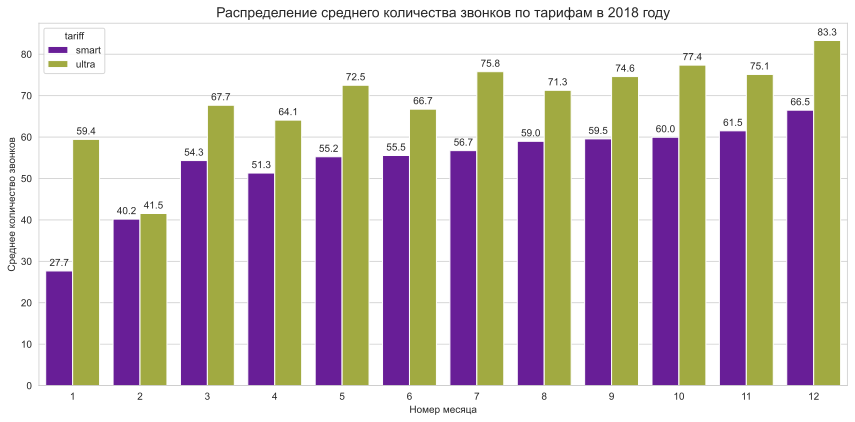

In [30]:
# визуализация: распределение среднего количества звонков по видам тарифов и месяцам
ax = sns.barplot(x='month', y='calls_mean', hue='tariff', data=stats_df, palette=['#6C0AAB', '#B0BC2F'])

# числовые значения над каждым столбцом
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
    
ax.set_title('Распределение среднего количества звонков по тарифам в 2018 году', fontsize=14)
ax.set(xlabel='Номер месяца', ylabel='Среднее количество звонков')
plt.tight_layout()
plt.show()

In [31]:
# описательные статистики количества звонков по видам тарифу
user_behavior.groupby('tariff')['calls'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tariff,,,,,,,,
smart,2229.0,58.46,25.94,0.0,40.0,60.0,76.0,198.0
ultra,985.0,73.39,43.92,0.0,41.0,74.0,104.0,244.0


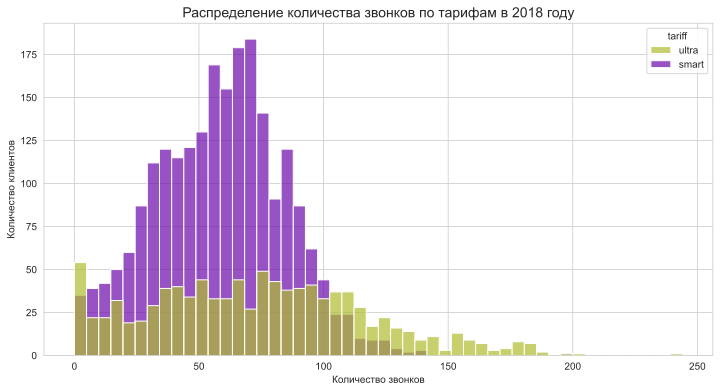

In [32]:
# визуализация: распределение количества звонков по видам тарифов
# при диапазоне значений 0 - 244 звонка, корзина в 50 бинов даёт ширину ~5 единиц — это позволяет визуально различать группы без визуального шума
sns.histplot(data=user_behavior, x='calls', hue='tariff', bins=50, palette=['#B0BC2F', '#6C0AAB'], alpha=0.7)
plt.title('Распределение количества звонков по тарифам в 2018 году', fontsize=14)
plt.xlabel('Количество звонков')
plt.ylabel('Количество клиентов')
plt.show()

**Вывод:** анализ статистики звонков показывает, что тариф `smart` является более популярным среди клиентов, на него приходится около 69% выборки (2229 абонентов против 985 абонентов тарифа `ultra`). При этом пользователи тарифа `ultra` демонстрируют более высокую активность в совершении звонков. В среднем, они совершают 73.4 звонка против 58.5 у абонентов тарифа `smart`, а медианные значения (74 `ultra` и 60 звонков `smart` соответственно) подтверждают, что эта разница не является случайной или обусловленной лишь несколькими выбросами.

Также полагаем важным отметить, что поведение абонентов на тарифе `ultra` характеризуется гораздо большей неоднородностью. Стандартное отклонение в этой группе составляет 43.9 звонка против 25.9 у `smart`, что означает почти в 1.5 раза более широкий разброс значений. Иными словами, в составе абонетов тарифа `ultra` есть и очень пассивные, так и сверхактивные абоненты, тогда как клиенты тарифа `smart` ведут себя куда боллее предсказуемо и равномерно. Этот вывод подкрепляется и расчётами коээфициента вариации (отношение стандартного отклонения к среднему значению): 60% для тарифа `ultra` и 44% для тарифа `smart`.

При детальном рассмотрении очевидным становится **ключевое различие между тарифами**, сформированное за счёт верхней части распределения. Нижняя четверть абонентов в обеих группах звонит примерно одинаково (40-41 звонок), однако, уже на уровне медианы разрыв достигает 14 звонков, а верхнем квартире абоненты тарифа `ultra` совершают в среднем 104 звонка против 76 у абонентов тарифа `smart`. Именно эта группа наиболее активных пользователей тянет вверх среднее значение по тарифу `ultra` и формирует его профиль как более общительного.

Присутствие нулевых значений в обеих группах указывает на наличие абонентов, которые не совершают звонков вовсе. Это может быть связано с особенностями онбординга новых абонентов, с использованием тарифа преимущественно для интернета, со спящим статусом номера или с тем, что клиент уже находится в процессе оттока. Отточность клиентов как явление заслуживаети отдельного изучения, особенно в контексте задачи удержания клиентов.

С практической точки зрения эти наблюдения позволяют сформулировать несколько рекомендаций. Для тарифа `ultra` целесообразно выделить сегмент сверхактивных пользователей (более 75-100 звонков) и предложить им персонализированные условия или программы лояльности, так как именно они генерируют значительную часть трафика. Для тарифа `smart` с более однородной аудиторией, будут эффективнее работать массовые коммуникации и стандартизированные предложения, при этом, абонентов, приближающихся к верхней границе своего распределения (около 75 звонков), можно рассматривать как кандидатов на апсейл.

**Основное различие между тарифами заключается** не в поведении так называемого типичного клиента, а **в структуре верхней части распределения**: тариф `ultra` привлекает или формирует более активную и разнообразную аудиторию, и именно эта группа может быть ключевым драйвером как нагрузки на сеть, так и потенциальной выручки. 

<a id=3.5.2.></a>
### 3.5.2. Распределение продолжительности звонков

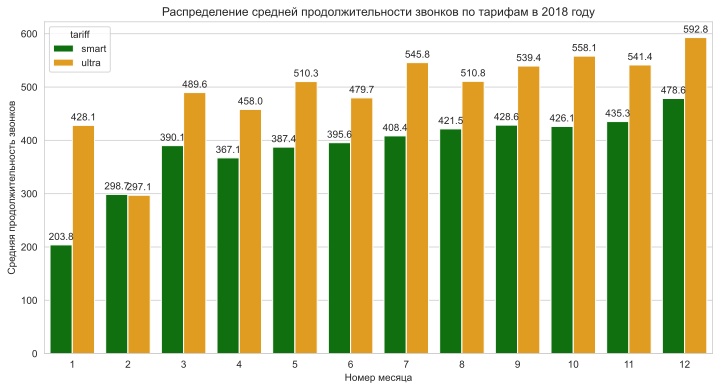

In [33]:
# визуализация: распределение средней продолжительности звонков по видам тарифов и месяцам
ax = sns.barplot(x='month', y='minutes_mean', hue='tariff', data=stats_df, palette=['green', 'orange'])

# числовые значения над каждым столбцом
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
    
ax.set_title('Распределение средней продолжительности звонков по тарифам в 2018 году')
ax.set(xlabel='Номер месяца', ylabel='Средняя продолжительность звонков');

In [34]:
# описательные статистики длительности звонков по каждому тарифу
user_behavior.groupby('tariff')['minutes'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tariff,,,,,,,,
smart,2229.0,417.93,190.31,0.0,282.0,422.0,545.0,1435.0
ultra,985.0,526.62,317.61,0.0,284.0,518.0,752.0,1673.0


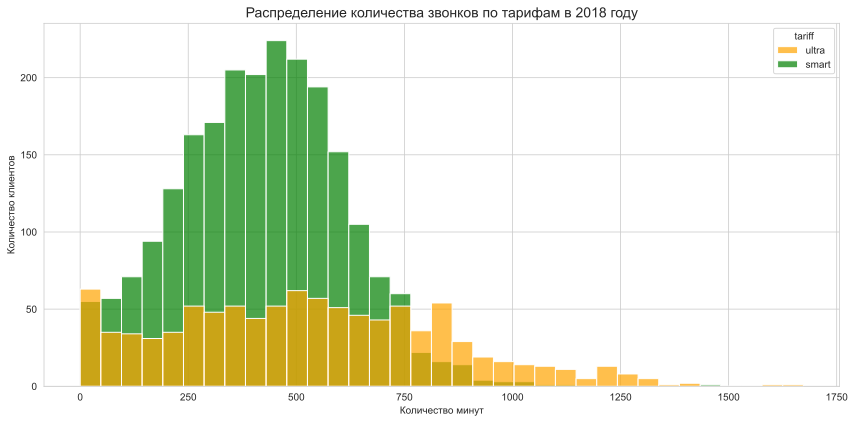

In [35]:
# распределение длительности звонков по видам тарифов
sns.histplot(data=user_behavior, x='minutes', hue='tariff', bins=35, palette=['orange', 'green'], alpha=0.7)
plt.title('Распределение количества звонков по тарифам в 2018 году', fontsize=14)
plt.xlabel('Количество минут')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Вывод:** средняя продолжительность разговоров у абонентов тарифа `ultra` больше, чем у абонентов тарифа `smart`. В течение года пользователи обоих тарифов увеличивают среднюю продолжительность своих разговоров. Рост средней длительности разговоров у абонентов тарифа `smart` равномерный в течение года. Пользователи тарифа `ultra` не  проявляют подобной линейной стабильности. Стоит отметить, что в феврале у абонентов обоих тарифных планов наблюдались самые низкие показатели.

В поведении абонентов тарифов `smart` и `ultra` мы отчётливо видим существенные различия. Аудитория тарифа `ultra` уделяет гораздо больше времени разговорам: среднее значение длительности разговоров составляет 526.62 против 417.96 у тарифа `smart`. Эта разница, достигающая примерно 26%, указывает на то, что **пользователи более дорогого тарифа `ultra` в среднем, активнее и дольше общаются по сотовой связи и генерируют больший объём целевой метрики.** Одновременно с этим, важно отметить, что нижняя четверть абонентов обоих тарифов ведёт себя практически идентично: значения 25-го процентиля составляют 282 для тарифа `smart` и 284 для тарифа `ultra`, что говорит о схожем поведении наименее активной части аудитории вне зависимости от выбранного тарифа. 

Ключевое различие кроется в неоднородности данных. Тариф `ultra` характеризуется значительно более высоким стандартным отклонением (317.61 против 190.31) и широким межквартильным размахом, что свидетельствует о сильном разбросе значений внутри этой группы. Иными словами, аудитори тарифа `ultra` менее предсказуема: наряду с пользователями, чьи показатели близки к тарифу `smart`, здесь присутствует заметная доля клиентов с экстремально высокими значениями. Именно они формируют отрыв по средним показателям: 75-й процентиль у абонентов тарифа `ultra` достигает 752 минуты, тогда как у абонентов тарифа `smart` - только 545 минут. Максимальные значения только подтверждают эту тендунцию. 

Наличие нулевых значений по длительности разговоров в обеих группах получает своё продолжение, как логическая смысловая часть предыдущего пункта исследования. Существует определённая группа пользователей, которые не используют сотовую связь для разговоров. 

Таким образом, тариф `smart` представляет собой стабильный и однородный сегмент с предсказуемым поведением, а тариф `ultra` являет группу абонентов с высоким потенциалом и с большей вариативностью. Для эффективного управления этими сегментами целесообразно сосредоточить усилия на удержании наиболее активных абонентов тарифа `ultra`, которые вносят ключевой вклад в средние показатели. При этом, для тарифа `smart` перспективным направлением может стать стиумлирование пользователей из среднего диапазона к более активному использованию сотовой связи для общения.

<a id=3.5.3.></a>
### 3.5.3. Распределение количества сообщений

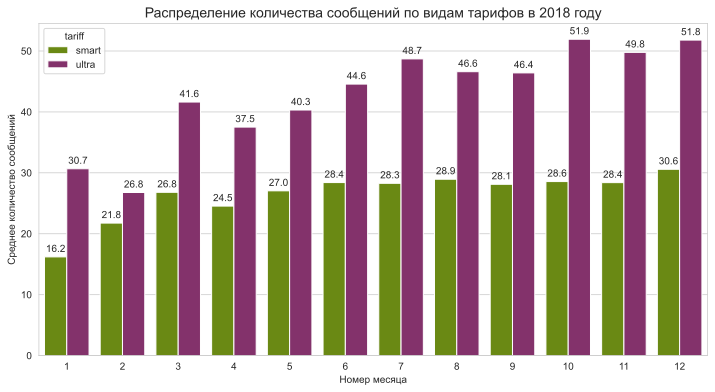

In [36]:
# распределение среднего количества сообщений по видам тарифов и месяцам
ax = sns.barplot(x='month', y='messages_mean', hue='tariff', data=stats_df, palette=['#739D00', '#912470'])

# числовые значения над каждым столбцом
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

ax.set_title('Распределение количества сообщений по видам тарифов в 2018 году', fontsize=14)
ax.set(xlabel='Номер месяца', ylabel='Среднее количество сообщений');

In [37]:
# описательные статистики количества сообщений по каждому тарифу
user_behavior.groupby('tariff')['messages'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tariff,,,,,,,,
smart,2229.0,33.38,28.23,0.0,10.0,28.0,51.0,143.0
ultra,985.0,49.36,47.80,0.0,6.0,38.0,79.0,224.0


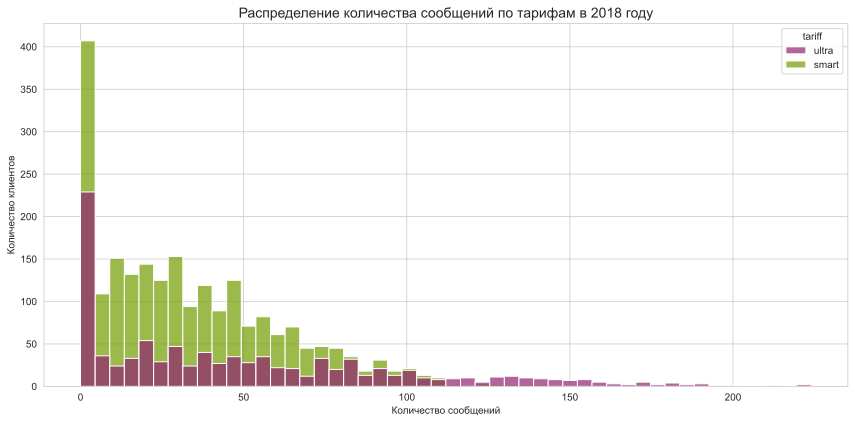

In [38]:
# распределение количества сообщений по видам тарифов
sns.histplot(data=user_behavior, x='messages', hue='tariff', bins=50, palette=['#912470', '#739D00'], alpha=0.7)
plt.title('Распределение количества сообщений по тарифам в 2018 году', fontsize=14)
plt.xlabel('Количество сообщений')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Вывод:** количество отправленных абонентами sms-сообщений в течение года на обоих тарифах растёт. Динамика схожа с тендениями по длительности разговоров: в феврале отмечено наименьшее количество сообщений в году, пользователи тарифа `ultra` также проявляют нелинейную положительную динамику. В среднем абоненты тарифа `ultra` отправляют больше сообщений - почти на 20 sms больше, чем абоненты тарифа `smart`.

Описательные статистики показывают интеренсые и неоднозначные различия в распределении показателя между тарифами `smart` и `ultra`. В первую очередь, бросается в глаза, что пользователи тарифа `ultra` демонстрируют более высокие средние и медианные значения. Разница в средних значениях достигает почти 48% (49 против 33), что на первый взгляд указывает на существенно более высокую активность или потребление в тарифе `ultra`. Однако, при более детальном изучении распределния становится очевидно, что эта **разница формируется** не за счёт равномерного превосходства по всем уровням, а **благодаря сильной поляризации данных внутри абонентов тарифа `ultra`**. Особенно показательным является поведение абонентов в нижнем и верхнем квартилях. Если обратить внимание на 25-й процентиль, то окажется, что у тарифа `ultra` он даже ниже, чем у тарифа `smart`: 6 против 10. Это означает, что **наименее активная четверть абонентов тарифа `ultra` отправляет меньше сообщений, чем аналогичная группа на тарифе `smart`.** В то же самое время, верхняя граница условного средннего класса (75-й процентиль) у тарифа `ultra` значительно выше: 79 против 51. Таким образом, **аудитория тарифа `ultra` характеризуется более широким разбросом поведения: в ней одновременно присуствует и больше совсем неактивных пользователей, там и больше абонентов с экстремально высокими показателями.** Это подтверждается и стандартным отклонением, которое у тарифа `ultra` почти в 1.7 раза выше, чем у `smart` (47.8 против 28.23), что свидетельсвует о существенной неоднородности этой группы.

Наличие нулевых значений в обеих подгруппах (минимум равен 0) указывает на присутствие пользователей, которые не пользуются sms-сообщениями вовсе. Максимальные значения в подгруппах тарифов также различаются: 224 у тарифа `ultra` против 143 у тарифа `smart`, что в очередной раз подтверждает наличие в группе тарифа `ultra` абонентов с аномально высокой активностью, способных существенно влиять на средние показатели.

Мы в очередной раз получили подтверждение стабильности и предсказуемости сегмента абонентов на тарифе `smart` с умеренным разбросом показателей и более равномерным распределением активности отправки sms-сообщений. Тариф `ultra`, напротив, объединяет крайне разнородную аудиторию: здесь сконцентрированы как самые пассивные, так и самые активные пользователи. Такая структура открывает различные возможности для работы с каждым сегментом: для абонентов `ultra` целесобразно выделять группу высоких потребителей для персонализированного удержания, одновременно прорабатывая причины низкой активности и самого нижнего квантиля. Для тарифа `smart` стратегия может быть направлена на постепенную стимуляцию увеличения количества sms-сообщений у основной массы пользователей, чьё поведение более однородно и лучше поддаётся прогнозированию.

<a id=3.5.4.></a>
### 3.5.4. Распределение количества потраченного трафика (Мб)

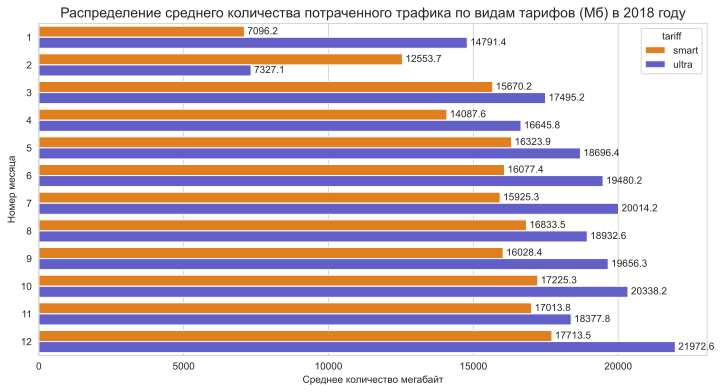

In [39]:
# распределение среднего количества потраченного трафика по видам тарифов и месяцам
ax = sns.barplot(x='sessions_mean', y='month', hue='tariff', data=stats_df, palette=['#FF7F00', '#514ED9'], orient='h')

# числовые значения над каждым столбцом
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
    
ax.set_title('Распределение среднего количества потраченного трафика по видам тарифов (Мб) в 2018 году', fontsize=14)
ax.set(xlabel='Среднее количество мегабайт', ylabel='Номер месяца');

In [40]:
# описательные статистики количества сообщений по каждому тарифу
user_behavior.groupby('tariff')['mb_used'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
tariff,,,,,,,,
smart,2229.0,16208.39,5870.48,0.0,12643.01,16506.84,20042.93,38552.45
ultra,985.0,19468.81,10087.17,0.0,11770.26,19308.01,26837.69,49745.69


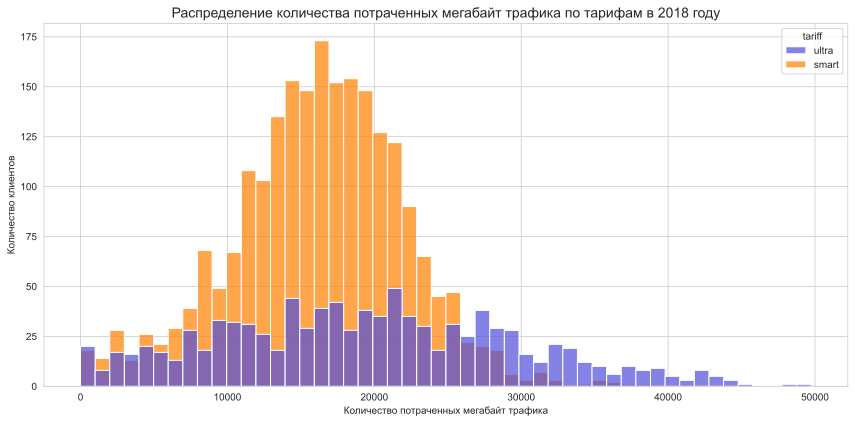

In [41]:
# распределение количества потраченных мегабайт трафика по видам тарифов
sns.histplot(data=user_behavior, x='mb_used', hue='tariff', bins=50, palette=['#514ED9', '#FF7F00'], alpha=0.7)
plt.title('Распределение количества потраченных мегабайт трафика по тарифам в 2018 году', fontsize=14)
plt.xlabel('Количество потраченных мегабайт трафика')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Вывод:** меньше всего пользователи обоих тарифов пользовались интернетом в январе, феврале и апреле. Анализ данных о потреблении интернет-трафика пользователями тарифов `smart` и `ultra` вновь подчёркивает принципиально разную структуру поведения этих двух сегментов аудитории. В целом, абоненты тарифа `ultra` действительно потребляют больше трафика: среднее значение составляет 19 Гб против 15.8 Гб на тарифе `smart`, что соответствует разнице примерно в 20%. Медианные значения подтверждают эту тендженцию. Однако, при более детальном рассмотрении распределения становится очевидным, что это превосходство вновь сформировано сильной поляризацией абонентов внутри тарифа `ultra`.

Особенно показательным здесь является поведение нижнего квартиля: 25-й процентиль тарифа `ultra` составляет 11.5 Гб, что ещё ниже, чем аналогичная метрика на тарифе `smart` в 12.34 Гб. Это означает, что наименее активная четверть пользователей более дорогого тарифа `ultra` на самом деле потребляет меньше трафика, чем аналогичная группа на базовом тарифе `smart`. В то же самое время, граница так называемого среднего класса (75-й процентиль) дорогого тарифа `ultra` существенно выше: 26.2 Гб против 19.54 Гб. Таким образом, аудитория тарифа `ultra` характеризуется значительно более широким разбросом поведения и по этому признаку. В ней одновременно сконцентрированы и самые пассивные, и самые активные абоненты. Это утверждение подкреплено также значениями стандартного отклонения, которое на тарифе `ultra` почти в 1.7 раза выше, чем на тарифе `smart`, что свидетельствует о существенной неоднородности этой группы.

Наличие нулевых значений в обеих выборках указывает на пользователей, которые в отчётном периоде не пользовались Интернет-трафиком вовсе. При этом более низкий первый квартиль у абонентов тарифа `ultra` может косвенно свидетельствовать о том, что доля таких неактивных абонентов в этом сегменты выше. Максимальные значения также различаются радикально: 48.58 Гб у `ultra` против 37.65 Гб у `smarta`, что явно указывает на наличие в группе `ultra` клиентов с экстремально высоким потреблением Интернет-трафика, способных существенно влиять на средние показатели.

Показательным для исследования также может быть и сам размер выборок: тариф `smart` представлен 2229 наблюдениями, тогда как `ultra` - только 985. Это соотношение может отражать как разницу в популярности тарифных планов, так и особенности текущей клиентской базы, в которой `smart` выступает как массовый продукт, а `ultra` - как премиальный сегмент с более узкой, но потенциально более ценной аудиторией.

Такая структура данных открывает возможности разных подходов для работы с каждым сегментом. Так, для абонентов тарифа `ultra` целесообразно выделять группу высоких потребителей для персонализированного удержания и развития, при этом обпратить внимание на причины низкой активности нижнего квартиря - возможно, эти абоненты переплачивают за неиспользуемый ресурс и находятся в зоне риска оттока. Для тарифа `smart` стратегия может быть направлена на постепенную стимуляцию роста потребления Интернет-трафика у основной массы пользователей, чьё поведение являет собой более однородный и цельный массив, и гораздо лучше поддаётся прогнозированию, например, через персонализированные предложения по увеличению пакета Интернет-трафика.

<a id=3.5.5.></a>
### 3.5.5. Выручка по городам

In [42]:
# выручка по городам
user_behavior.groupby('city')['total_cost'].sum().sort_values(ascending=False)

city
Москва             945042.0
Санкт-Петербург    436982.0
Новосибирск        174542.0
Уфа                145762.0
Краснодар          132790.0
                     ...   
Кемерово             9165.0
Владикавказ          8985.0
Волжский             6050.0
Иваново              3900.0
Химки                3192.0
Name: total_cost, Length: 76, dtype: float64

In [43]:
# топ-10 городов по выручке
user_behavior.groupby('city')['total_cost'].sum().sort_values(ascending=False).head(10).to_frame()

,total_cost
city,
Москва,945042.0
Санкт-Петербург,436982.0
Новосибирск,174542.0
Уфа,145762.0
Краснодар,132790.0
Пермь,108096.0
Ульяновск,106486.0
Нижний Новгород,103971.0
Омск,103317.0


Полученные данные о годовой суммарной выручке от услуг сотовой связи демонстрируют **выраженную иерархическую структуру рынка с высокой концентрацией дохода в городских агломерациях.** Безусловным лидером выступает Москва, сгенерировавшая 945042 рублей выручки, что более чем в 2 раза превышает показатель Санкт-Петербурга в 436982 рубля, и почти в 5.4 раза - показатель Новосибирска, замыкающего тройку лидеров. Такой разрыв подтверждает **статус столичного региона как ключевого драйвера дохода, аккумулирующего значительную долю общего рынка.**

**За пределами Москвы и Санкт-Петербурга**, двух городов-миллионников федерального значения, **наблюдается более плавная градация показателей.** Так, выручка в городах от Новосибирска до Набережных Челнов выучка варьируется в диапазон от 100 до 175 тысяч, формируя устойчивый «пояс» региональных центров с сопоставимым уровнем платёжеспособного спроса, при этом, разница между пятым (Краснодар, 132790) и десятым (Набережные Челны, 100762) местом составляет менее 32%, что свидетельствует о **высокой степени однородности рынка в сегменте крупных региональных городов.**

С точки зрения бизнес-логики такая структура указывается на **необходимость дифференцированного подхода к управлению**:

* для Москвы и Санкт-Петербурга приоритетом может быть удержание лояльности и монетизация премиального спроса;
* в региональных центрах будет целесообразно сместить фокус на массовое привлечение и оптимизацию тарифной архитектуры, поскольку здесь потенциал роста ограничен более однородной и чувствительной к цене аудиторией.

In [44]:
# собираем сводную таблицу с выручкой по месяцам в разрезе всех городов, добавляем общегодовую итоговую сумму 
cities = pd.pivot_table(user_behavior, index='city', columns='month', values='total_cost', aggfunc='sum', fill_value=0, margins=True, margins_name='итого')

# принудительно выставляем порядок столбцов: 1, 2, ..., 12, итого
cols_order = [m for m in range(1, 13) if m in cities.columns]
if 'итого' in cities.columns:
    cols_order.append('итого')

# сводная таблица с городами в алфавитном порядке
cities = cities.reindex(columns=cols_order)

# создаём многоуровневую сортировку в порядке: итого, 12, 11, ..., 1
sort_cols = ['итого'] + [m for m in range(1,13) if m in cities.columns]

# применяем многоуровневую сортировку по убыванию для всех указанных столбцов
cities = cities.sort_values(by=sort_cols, ascending=False)
cities.head()

month,1,2,3,4,5,6,7,8,9,10,11,12,итого
city,,,,,,,,,,,,,
итого,42075.0,95401.0,164226.0,217966.0,306849.0,368759.0,438764.0,533240.0,557786.0,655367.0,704753.0,829265.0,4914451.0
Москва,11800.0,16452.0,32992.0,43596.0,57140.0,70534.0,81120.0,99244.0,105301.0,125371.0,143341.0,158151.0,945042.0
Санкт-Петербург,4000.0,10056.0,15918.0,18641.0,23341.0,33339.0,40934.0,47329.0,49228.0,63790.0,62117.0,68289.0,436982.0
Новосибирск,0.0,3900.0,4450.0,5850.0,10550.0,12809.0,15216.0,19400.0,22589.0,25142.0,23850.0,30786.0,174542.0
Уфа,1100.0,1752.0,9042.0,10781.0,14806.0,13032.0,13405.0,14994.0,13231.0,15613.0,15848.0,22158.0,145762.0


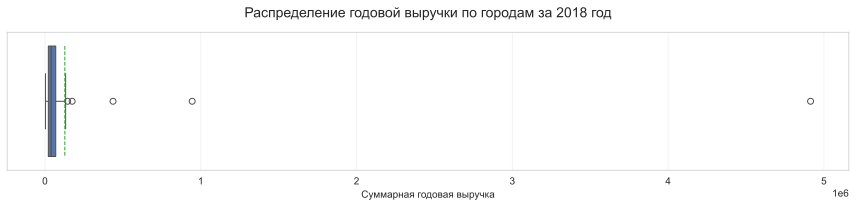

In [45]:
# визуализация: диаграмма «ящик с усами»
plt.figure(figsize=(12, 3))
ax = sns.boxplot(data=cities, x='итого', color='#4C72B0', showmeans=True, meanline=True)
ax.set_title('Распределение годовой выручки по городам за 2018 год', fontsize=14, pad=15)
ax.set_xlabel('Суммарная годовая выручка')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

На графике мы отчётливо видим выбросы в данных, зафиксированные в топ-5 городов по суммарной годовой выручке оператора сотовой связи компании «Мегалайн». Изучим аналогичный график без учёта лидеров рынка.

In [46]:
# выделяем прочие региональные центры в отдельный датафрейм
cities_top5 = cities['итого'].nlargest(5).index
cities_regional = cities.drop(index=cities_top5)
cities_regional.head()

month,1,2,3,4,5,6,7,8,9,10,11,12,итого
city,,,,,,,,,,,,,
Краснодар,1950.0,3050.0,4720.0,6370.0,11214.0,11658.0,12155.0,14140.0,16221.0,17081.0,16441.0,17790.0,132790.0
Пермь,0.0,1100.0,5118.0,7807.0,8923.0,10611.0,12550.0,12166.0,12020.0,13327.0,12578.0,11896.0,108096.0
Ульяновск,2900.0,3150.0,6977.0,5361.0,6470.0,6787.0,8825.0,11468.0,10895.0,11033.0,13721.0,18899.0,106486.0
Нижний Новгород,0.0,2250.0,1950.0,3500.0,7311.0,10007.0,7943.0,10875.0,10521.0,11839.0,15877.0,21898.0,103971.0
Омск,750.0,550.0,1300.0,2654.0,3176.0,9640.0,11682.0,14353.0,13859.0,13515.0,13866.0,17972.0,103317.0


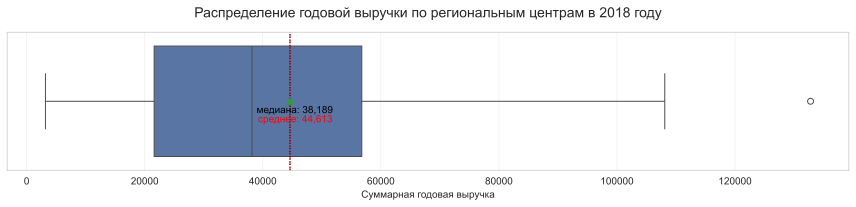

In [47]:
# визуализация: боксплот по выручке в региональнызх центрах без учёта топ-5 лидеров рынка
plt.figure(figsize=(12, 3))
ax = sns.boxplot(data=cities_regional, x='итого', color='#4C72B0', showmeans=True)

# добавляем метки со средним и медианным значением
mean_val = cities_regional['итого'].mean()
median_val = cities_regional['итого'].median()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1)
ax.axvline(mean_val, color='black', linestyle=':', linewidth=1)
ax.text(mean_val * 1.02, 0.1, f'среднее: {mean_val:,.0f}', color='red', fontsize=10, va='top', ha='center')
ax.text(median_val * 1.02, 0.1, f'медиана: {median_val:,.0f}', color='black', fontsize=10, va='bottom')

ax.set_title('Распределение годовой выручки по региональным центрам в 2018 году', fontsize=14, pad=15)
ax.set_xlabel('Суммарная годовая выручка')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

После исключения Москвы, Санкт-Петербурга, Новосибирска, Уфы и Краснодара, ящик боксплота стал значительно компактее, и усы - короче. Это наглядно показывает, насколько сильно топ-5 искажали общую картину разброса: без них распределение выручки по оставшимся ~70 городам представляется более однородным, с меньшим количеством выбросов и меньшей дисперсией.

In [48]:
# подготовка данных
values = cities_regional['итого'].values

# установление отметок квартилей
Q1, Q2, Q3 = np.quantile(values, [0.25, 0.50, 0.75])

# создаём категории на основе перцентилей итоговой годовой выручки
# q=4 - это 4 квартиля: Q1, Q2, Q3, Q4
# отбрасываем дубликаты в том случае, если значения на границах совпадают
cities_regional['сегмент'] = pd.qcut(cities_regional['итого'], q=4, duplicates='drop',\
                                             labels=['низкий', 'средний-', 'средний+', 'высокий'])
cities_regional.head()

month,1,2,3,4,5,6,7,8,9,10,11,12,итого,сегмент
city,,,,,,,,,,,,,,
Краснодар,1950.0,3050.0,4720.0,6370.0,11214.0,11658.0,12155.0,14140.0,16221.0,17081.0,16441.0,17790.0,132790.0,высокий
Пермь,0.0,1100.0,5118.0,7807.0,8923.0,10611.0,12550.0,12166.0,12020.0,13327.0,12578.0,11896.0,108096.0,высокий
Ульяновск,2900.0,3150.0,6977.0,5361.0,6470.0,6787.0,8825.0,11468.0,10895.0,11033.0,13721.0,18899.0,106486.0,высокий
Нижний Новгород,0.0,2250.0,1950.0,3500.0,7311.0,10007.0,7943.0,10875.0,10521.0,11839.0,15877.0,21898.0,103971.0,высокий
Омск,750.0,550.0,1300.0,2654.0,3176.0,9640.0,11682.0,14353.0,13859.0,13515.0,13866.0,17972.0,103317.0,высокий


In [49]:
# получаем список региональных городов
cities_regional_list = cities_regional.index.tolist()

In [50]:
# на исходных данных считаем среднюю выручку по тарифам для каждого регионального центра
cities_regional_mean_cost = (user_behavior[user_behavior['city'].isin(cities_regional_list)]
                .groupby(['city', 'tariff'])['total_cost']
                .sum().reset_index())

In [51]:
# объединяем полученные данные по средней выручке по региональным центрам с данными по сегментам
tariff_stats = cities_regional_mean_cost.merge(cities_regional[['сегмент']].reset_index(), on='city', how='left')
tariff_stats.head()

,city,tariff,total_cost,сегмент
0,Архангельск,smart,15559.0,низкий
1,Астрахань,smart,32485.0,средний+
2,Астрахань,ultra,9750.0,средний+
3,Балашиха,smart,26599.0,средний+
4,Балашиха,ultra,19500.0,средний+


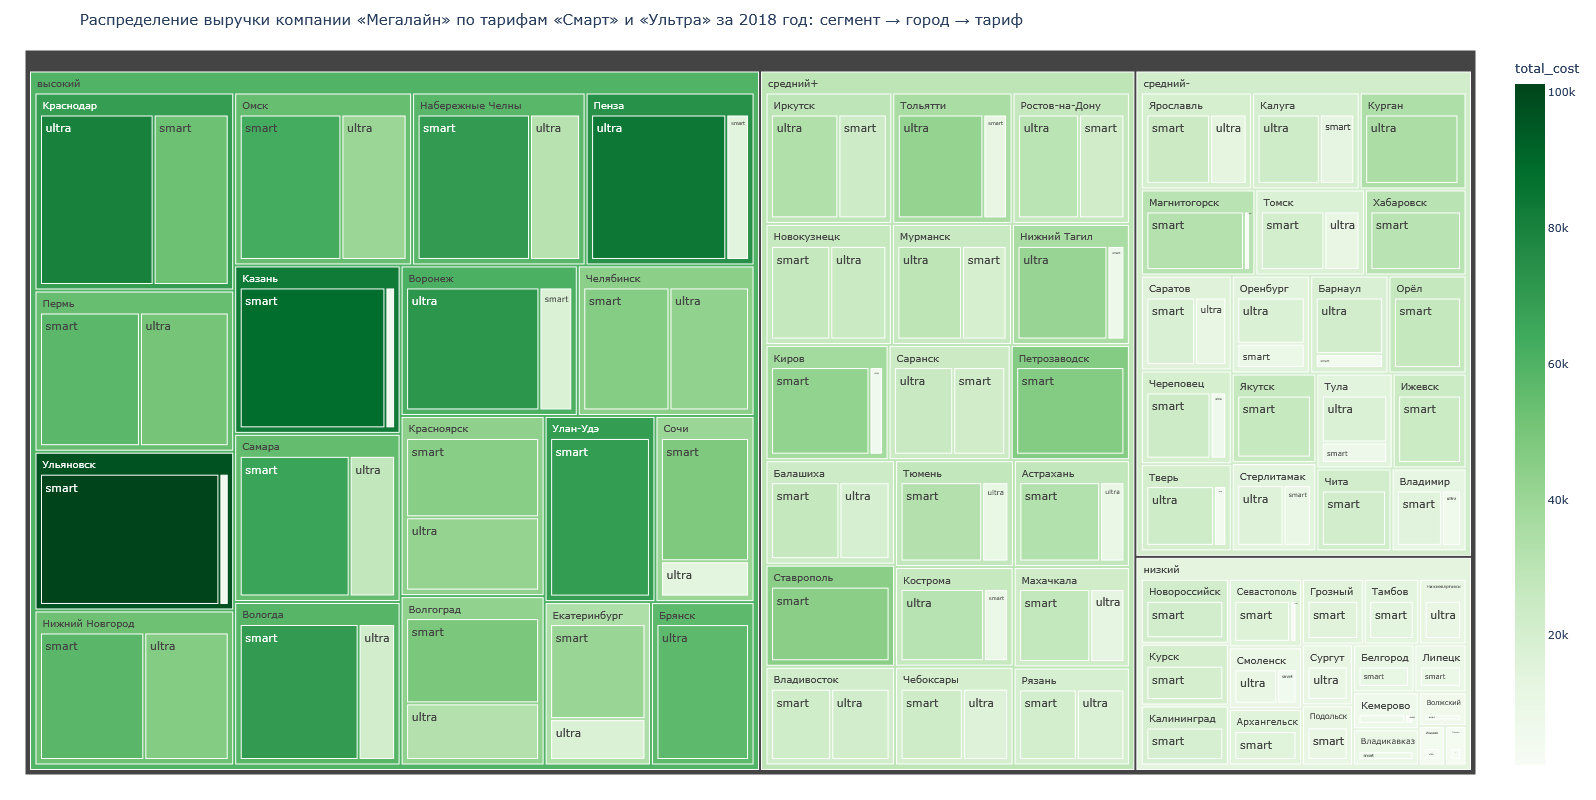

In [52]:
# иерархическая сортировка по сегментам
tariff_stats['сегмент'] = pd.Categorical(tariff_stats['сегмент'], 
                                categories=['низкий', 'средний-', 'средний+', 'высокий'], 
                                ordered=True)
tariff_stats_sorted = tariff_stats.sort_values(['сегмент', 'city', 'tariff'])

# визуализация: Treemap
# вложенность: сегмент → город → тариф
fig = px.treemap(tariff_stats_sorted, 
                 path=['сегмент', 'city', 'tariff'], 
                 values='total_cost',
                 color='total_cost',
                 color_continuous_scale='greens',
                 title='Распределение выручки компании «Мегалайн» по тарифам «Смарт» и «Ультра» за 2018 год: сегмент → город → тариф')

# параментры отображения графика
fig.update_layout(height=800, margin=dict(t=50, l=25, r=25, b=25), font=dict(size=11))
fig.show()

# сохранение интерактивного графика в формате *.html
fig.write_html('2018_smart_ultra_revenue.html')

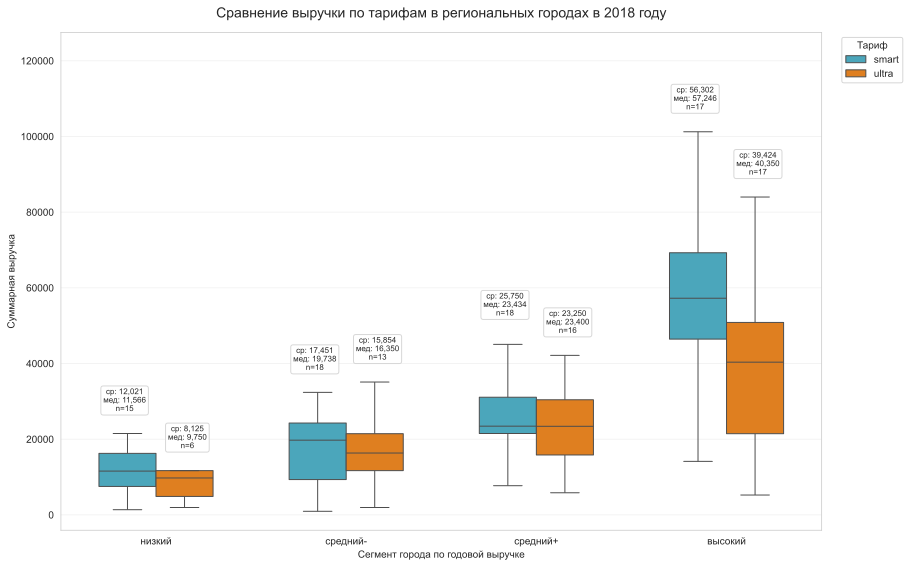

In [53]:
# расчёт описательных статистик по сегментам
stats = (tariff_stats
         .groupby(['сегмент', 'tariff'], observed=True)['total_cost']
         .agg(['mean', 'median', 'count'])
         .round(0)
         .reset_index())

seg_order = ['низкий', 'средний-', 'средний+', 'высокий']
tariff_order = tariff_stats['tariff'].unique()

# Приводим к категориальному типу для однозначной сортировки
stats['сегмент'] = pd.Categorical(stats['сегмент'], categories=seg_order, ordered=True)
stats['tariff']   = pd.Categorical(stats['tariff'], categories=tariff_order, ordered=True)
stats_sorted = stats.sort_values(['сегмент', 'tariff']).reset_index(drop=True)

# визуализация: сравнение тарифов внутри сегментов региональных центров
width = 0.6  # фиксированная ширина боксплотов для точного расчёта отступов
plt.figure(figsize=(14, 8))
ax = sns.boxplot(data=tariff_stats, x='сегмент', y='total_cost', 
                 hue='tariff', hue_order=tariff_order,
                 palette=['#38B2CE', '#FF7F00'], 
                 order=seg_order, showfliers=False, width=width)

# рассчитаем X-координаты центров боксплотов математически
n_tariffs = len(tariff_order)
step = (width * 1.1) / n_tariffs

for i, segment in enumerate(seg_order):
    for j, tariff in enumerate(tariff_order):
        
        # точный центр боксплота по оси X
        x_center = i + (j - (n_tariffs - 1) / 2) * step 
        
        # берём статистику для текущей пары сегмент - тариф
        row = stats_sorted[(stats_sorted['сегмент'] == segment) & (stats_sorted['tariff'] == tariff)].iloc[0]
        
        # задаём динамический отступ по оси Y
        mask = (tariff_stats['сегмент'] == segment) & (tariff_stats['tariff'] == tariff)
        y_max = tariff_stats.loc[mask, 'total_cost'].max()
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_pos = y_max + y_range * 0.05

        # формируем сами лейблы с данными описательной статистики: среднее, медиана, количество городов в сегменте
        label = f'ср: {row["mean"]:,.0f}\nмед: {row["median"]:,.0f}\nn={int(row["count"])}'

        # форматирование текста в лейблах
        ax.text(x_center, y_pos, label, ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                          edgecolor='lightgray', alpha=0.9))

# оформление графика
ax.set_title('Сравнение выручки по тарифам в региональных городах в 2018 году', fontsize=14, pad=15)
ax.set_xlabel('Сегмент города по годовой выручке')
ax.set_ylabel('Суммарная выручка')
plt.legend(title='Тариф', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

# освобождаем место на графике сверху
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.2)
plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.show()

**Вывод:** данные по сегментации рынка сотовой связи по тарифам `smart` и `ultra` в региональных городах России выявляют устойчивую иерархию предпочтений абонентов и чёткую зависимость между уровнем экономического развития города и структурой выручки.

В сегменте городов с `низкой` годовой выручкой тариф `smart` демонстрирует уверенное лидерство: средняя выручка на город составляет 12021 рубль против 8125 рублей у тарифа `ultra`, что даёт преимущество в 48%. При этом тариф `smart` представлен в 15 городах, тогда как `ultra` - лишь только в 6 городах. Это указывает на то, что в регионах с ограниченной платёжеспособностью абоненты отдают предпочтение более доступному и, вероятно, более гибкому продукту, тогда как премиальный `ultra` воспринимается как избыточный или неоправданно дорогой для данной аудитории.

По мере перехода в сегмент `средний-` разрыв между тарифами существенно сокращается: средняя выручка `smart` составляет 17451 рубль, `ultra` - 15854 рубля (преимущество находится на уровне порядка 10%). Одновременно с этим, растёт количество городов, выбирающих `ultra` (рост с 6 до 13), что свидетельствует о постепенном проникновении премиального продукта в города со средним уровнем дохода. Примечательно, что медианные значения в этом сегменте сближаются ещё сильнее (19738 против 16350 рублей), что говорит о выравнивании так называемого типичного поведения абонентов: в городах этой сегментной группы разница в восприятии тарифов становится менее выраженной.

В сегменте `средний+` тарифы практически уравновешиваются по эффективности. Средняя выручка тарифа `smart` 25750 рублей, `ultra` 23250 рублей, а медианы оказываются почти идентичными (23434 и 23400 рублей соотвественно). Количество городов, использующих каждый из тарифов, также выравнивается (18 против 16). И это очень важный инсайт: **в городах с доходом выше среднего абоненты перестают делать однозначный выбор в пользу одного продукта** - оба тарифа находят свою аудиторию, ит конкуренция смещается из плоскости цены в плоскость качества сервиса, покрытия или дополнительных опций. 

Наиболее показательным оказывается сегмент `высокий`. Здесь тариф `smart` не просто сохраняет лидерство, но и радикально усиливает отрыв: средняя выручка достигает 56302 рублей против 39424 рублей у `ultra` (отрыв составляет 43%). При этом количество городов, использующих каждый тариф, одинаково (по 17), что исключает объяснение за счёт более широкого охвата. Высокие значения как среднего, так и медианного показателя для тарифа `smart` (57246 рублей) указывают на то, что в наиболее платёжеспособных регионах этот тариф не просто популярен, но и генерирует экстремально высокую выручку - возможно, за счёт подключения корпоративных клиентов, активного использования дополнительных услуг или более высокой средней длительности разговоров. Тариф `ultra`, несмотря на премиальное позиционирование, в этом сегменте не способен конкурировать по монетизации, что может говорить о несоответствии его ценностного предложения реальным потребностям аудитории в крупнейших региональных центрах.

Таким образом, рынок демонстрирует нелинейнеую динамику: тариф `smart` оказывается универсальным продуктом, эффективным как в регионах с низким уровнем дохода, так и с высоким уровнем дохода, тогда как **тариф `ultra`** находит устойчивый спрос преимущественно в городах среднего и выше среднего уровня дохода, но **не реализует свой потенциал в самых доходных локациях.** Для бизнеса это означает, что **стратегия продвижения тарифа `ultra` требует пересмотра**: либо необходимо адаптировать его функционал и ценовую архитектуру под запросы аудитории в высокодоходных городах, либо сосредоточить ресурсы на масштабировании **тарифа `smart`, который уже доказал свою способность монетизировать любой сегмент рынка.**

В регионах с низкой выручкой приоритетом остаётся удержание и развитие клиентской базы тарифа `smart`, тогда как в средних сегментах имеет смысл тестировать гибридные предложения, способные конвертировать растущий интерес к тарифу `ultra` в устойчивую выручку.

<a id=4></a>
## Шаг 4. Проверка статистических гипотез

<a id=4.1.></a>
### 4.1. Проверка гипотезы: средняя выручка пользователей тарифов «Ультра» и «Смарт» различается

В нашем распоряжении не только агрегированные данные и дополнительные построения боксплотов в разрезе каждого сегмента, но и статистические методы. Выаполним статистическую проверку гипотезы: существует ли реальная разница в средней выручке пользователей услуг между абонентами тарифов `smart` и `ultra`. Для этого применяется `двухвыборочный t-критерий Стьюдента для независимых групп` , при этом аргумент `equal_var=False` активирует модификацию Уэлча, которая не требует предположения о равенстве дисперсий в сравниваемых выборках. Это делает тест более надёжным в реальных условиях, когда разброс доходов по одному тарифу может существенно отличаться от разброса по другому.

В основе проверки лежит **нулевая гипотеза**, которая утверждает, что **средние значения выручки по обоим тарифам статистически идентичны, а любые наблюдаемые отклонения вызваны лишь случайной вариативностью данных.** 

Вычислим `p-значение` - вероятность получить такие или ещё более выраженные различия между группами при условии, что нулевая гипотеза на самом деле верна. Затем полученное p-значение сравним с заданным уровнем значимости $ \alpha = 0.05$, который задаёт **пятипроцентный порог** допустимой ошибки первого рода, то есть **риска обнаружить различие там, где его нет**.

Если p-значение окажется меньще 0.05, то мы можем отвергнуть нулевую гипотезу. Следовательно, разница в средних расходах между тарифами статистически значима и с высокой долей уверенности отражает реальное влияние типа тарифа на итоговую стоимость. В противном случае, когда p-значение превышает 0.05, код сообщает, что нулевую гипотезу не удалось отвергнуть, то есть наблюдаемый разрыв в средних значениях укладывается в пределы естественного статистического шума и не может считаться достоверным. 

Итак, сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : выручка пользователей тарифа «Ультра» } = \text{выручка пользователей тарифа «Смарт»}
   \\
   \text{H}_1 \text{ : выручка пользователей тарифа «Ультра»} \neq \text{выручка пользователей тарифа «Смарт»}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [54]:
# вызов метода для проверки гипотезы
results = st.ttest_ind(
    user_behavior.loc[user_behavior.tariff == 'ultra', 'total_cost'],
    user_behavior.loc[user_behavior.tariff == 'smart', 'total_cost'], 
    equal_var=False)

# задаём значение уровня значимости
alpha = 0.05

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 4.2606313931076085e-250
Отвергаем нулевую гипотезу


**Вывод:** разница в средней выручке между тарифами «Ультра» и «Смарт» статистически значима и с высокой долей уверенности отражает реальное влияние вида тарифа на итоговую стоимость. На основе сырых данных о платежах абонентов нами был получен строгий статистический вывод, позволяющий отделить системные различия между тарифными планами от случайных колебаний, и принять обоснованное решение для дальнейшей маркетинговой стратегии.

<a id=4.2.></a>
### 4.2. Проверка гипотезы: средняя выручка с пользователей из Москвы отличается от выручки c пользователей других регионов

Аналогично предыдущему пункту исследования, здесь нами будет применён `двухвыборочный t-критерий Стьюдента для независимых групп` с параметром `equal_var=false`, который сразу отвергает равенство дисперсий двух групп, что особенно важно в данном случае, поскольку Москва, как крупнейший рынок, может демонстрировать принципиально иной разброс платежей по сравнению с объединённой группой региональных городов.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : выручка пользователей из Москвы } = \text{выручка пользователей не из Москвы»}
   \\
   \text{H}_1 \text{ : выручка пользователей из Москвы} \neq \text{выручка пользователей не из Москвы}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [55]:
# вызов метода для проверки гипотезы
results = st.ttest_ind(
    user_behavior.loc[user_behavior.city == 'Москва', 'total_cost'],
    user_behavior.loc[user_behavior.city != 'Москва', 'total_cost'], 
    equal_var=False)

# задаём значение уровня значимости
alpha = 0.05

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 0.5257376663729298
Не получилось отвергнуть нулевую гипотезу


**Вывод:** в данном конкретном случае `p-value` составило `0.526`, что существенно превышает уровень порогового значения `0.05`. Это означвает, что наблюдаемая разница в средних расходах между Москвой и остальными городами с высокой веротяностью укладывается в рамки естественного статистического шума. Нам не удалось доказать отсутствие различий, а только лишь констатировать, что имеющихся данных недостаточно для уверенного вывода о наличии статистически значимых различий.

С точки зрения бизнес-логики этот результат говорит о том, что вопреки абсолютному лидерству Москвы по суммарной выручке (а именно это мы многократно видели в ходе исследования), средняя стоимость оплаты услуг на одного абонента в столице не демонстрирует статистически значимого отклонения от общероссийского фона. Это может указывать на то, что тарифная архитектура и ценовая политика оператора обеспечивают сопоставимый уровень монетизации пользователя вне зависимости от географии, а коллоссальный разрыв в совокупной выручке Москвы объясняется исключительно масштабом абонентской базы, а не более высокими расходами отдельно взятого клиента. Для принятия управленческих решений полученные данные означают, что **стратегии ценообразования и удержания клиентов могут быть унифицированы для Москвы и регионов,** а **акценты в развитии столичного рынка целесообразно делать на привлечении новых абонентов**, а не на изменении условий для существующих.

<a id=5></a>
## Шаг 5. Вывод 

Проведённый статистический анализ прибыльности тарифов «Смарт» и «Ультра» компании «Мегалайн» позволяет следалть **однозначный вывод: тариф «Смарт» является более устойчивым и универсальным продуктом, обеспечивающим стабильную монетизацию абонентской базы в любых рыночных условиях**, тогда как тариф «Ультра», несмотря на премиальное позиционирование, демонстрирует высокую зависимость от специфики аудитории и не реализует весь свой потенциал в наиболее доходных сегментах.

Анализ поведения пользователей выявил **фундаментальное различие в структуре двух тарифных групп**: аудитория «Смарт» характеризуется однородностью и предсказуемостью, тогда как «Ультра» объединяет крайне поляризованную выборку, где наименее активные абоненты соседствуют со сверхактивными, формируя высокий разброс метрик. Именно эта неоднородность объясняет более высокие средние показатели по звонкам, сообшщениям и трафику в группе «Ультра». Однако, при сегментации городов по уровню выручки, обнаруживается парадокс: в наиболее платёжеспособных региональных центраз тариф «Смарт» не только сохраняет первенство, но и радикально усиливает отрыв, генерируя в среднем на 43% больше выручки на город. Это явно указывает на то, что в богатых регионах абоненты ценят гибкость и оптимальное соотношение цены и качества, которые предлагает «Смарт», тогда как «Ультра» находит устойчивый спрос преимущественно в городах среднего уровня, но не способен конкурировать в топовых локациях.

Статистическая проверка гипотез подтверждает, что **разница в средней выручке между тарифами является** не случайным колебанием, а **системным эффектом** (`p-value` < `0.001`), что даёт бизнесу надёжное основание для дифферинциованной стратегии продвижения. При этом, проверка гипотезы о различии Москвы и регионов показали отсутствие статистически значимой разницы в средней выручке на одного абонента, что свидетельствует об унифицированности ценовой политики и монетизации пользователя вне зависимости от географии: **колоссальный разрыв в совокупной выручке столицы объясняется исключительно масштабом абонентской базы Москвы**, а не более высокими расходами отдельного клиента.

Таким образом, в целях оптимизации рекламного бюджета и повышения общей прибыльности компании **целесообразно сделать тариф «Смарт» флагманским продуктом массового продвижения во всех регионах, включая Москву**, делая акцент на его универсальности и способности монетизировать любой тип потребления. **Тариф «Ультра» требует пересмотра ценностного предложения**: либо адаптации функционала под запросы аудитории высокодоходных городов, либо фокусировку на узком сегменте сверхактивных пользователейв регионах среднего уровня, где он уже доказал свою востребованность. Такой подход позволит максимизировать охват и выручку, опираясь на сильные стороны каждого продукта и избегая распыления ресурсов на неэффективные гипотезы.